In [11]:
import tensorflow as tf
import numpy as np
import pandas as pd
import cv2
import json
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [18]:
def apply_canny_edge_detection(image_path, target_size=(256, 256)):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    print('Image shape: ',image.shape)
    image = cv2.resize(image, target_size)
    edges = cv2.Canny(image, threshold1=50, threshold2=150)
    edges = np.stack((edges,) * 3, axis=-1)
    edges = edges / 255.0
    print('edges: ',edges.shape)
    return edges

def load_images(image_paths_transmitted, image_paths_reflected, target_size=(128, 128)):
    transmitted_images = [apply_canny_edge_detection(image_path, target_size) for image_path in image_paths_transmitted]
    reflected_images = [apply_canny_edge_detection(image_path, target_size) for image_path in image_paths_reflected]

    images = list(zip(transmitted_images, reflected_images))
    return np.array(images)

subdirs = ['Random_series/Random_series_001/', 'Random_series/Random_series_002/']

image_paths_transmitted = [f'./{subdir}Filtered_T_Image.tif' for subdir in subdirs]
image_paths_reflected = [f'./{subdir}Filtered_R_Image.tif' for subdir in subdirs]

# image_paths_transmitted = ['./Filtered_T_Image.tif']
# image_paths_reflected = ['./Filtered_R_Image.tif']

load_images(image_paths_transmitted, image_paths_reflected).shape

Image shape:  (656, 875)
edges:  (128, 128, 3)
Image shape:  (656, 875)
edges:  (128, 128, 3)
Image shape:  (656, 875)
edges:  (128, 128, 3)
Image shape:  (656, 875)
edges:  (128, 128, 3)


(2, 2, 128, 128, 3)

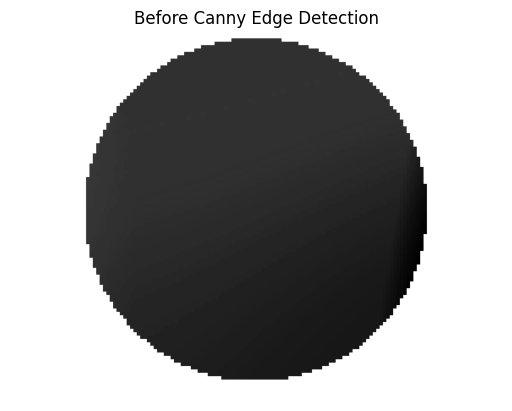

Image shape:  (656, 875)
edges:  (256, 256, 3)


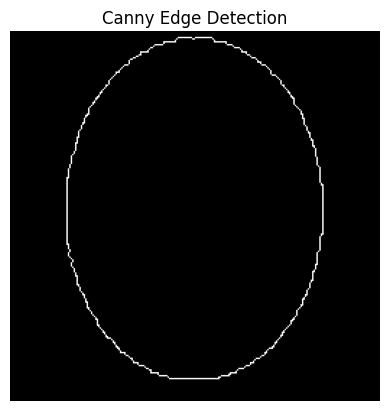

In [17]:
image = cv2.imread(image_paths_transmitted[0], cv2.IMREAD_GRAYSCALE)
plt.imshow(image, cmap='gray')
plt.title("Before Canny Edge Detection")
plt.axis('off')
plt.show()


edges = apply_canny_edge_detection(image_paths_transmitted[0])
plt.imshow(edges)
plt.title("Canny Edge Detection")
plt.axis('off')
plt.show()